# Quantification of Celltype/Stage mapping

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(reticulate)
    library(SingleCellExperiment)
    library(data.table)
    library(dplyr)
    library(gridExtra)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

ERROR: Error in library(biomaRt): there is no package called ‘biomaRt’


### I/O

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
mapping_dir = paste0(main, '07_atlas_mapping/')
out_dir = paste0(main, '08_mapping_quantification/')
dir.create(out_dir, showWarnings = FALSE)

source(paste0(main, "mapping_functions_extended.R"))

In [5]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

### Load data

In [3]:
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

In [4]:
table(meta$batch_name, meta$stage)

                            
                             E7.5 E8.5 E9.5
  SLX-21143_SITTA2_HTJH3DSX2    0 4020    0
  SLX-21143_SITTA4_HTJH3DSX2    0    0 4180
  SLX-21143_SITTB2_HTJH3DSX2    0 2705    0
  SLX-21143_SITTB4_HTJH3DSX2    0    0 3186
  SLX-21143_SITTC4_HTJH3DSX2    0    0 2403
  SLX-21143_SITTD4_HTJH3DSX2    0    0 2638
  SLX-21143_SITTD5_HTJH3DSX2 2075    0    0
  SLX-21143_SITTE3_HTJH3DSX2    0    0 1509
  SLX-21143_SITTE5_HTJH3DSX2  621    0    0
  SLX-21143_SITTF3_HTJH3DSX2    0    0 1935
  SLX-21143_SITTF5_HTJH3DSX2  324    0    0
  SLX-21143_SITTG1_HTJH3DSX2    0 1287    0
  SLX-21143_SITTG3_HTJH3DSX2    0    0 1632
  SLX-21143_SITTG5_HTJH3DSX2 1794    0    0
  SLX-21143_SITTH1_HTJH3DSX2    0 4012    0
  SLX-21143_SITTH3_HTJH3DSX2    0    0 3999

In [7]:
head(meta,2)

,closest.cell,cell,Sample_name,barcode,batch,batch_name,tdTom,index,sample,stage,...,umap_2,louvain_cluster,celltype.mapped,celltype_original.mapped,stage.mapped,celltype.score,celltype_original.score,cellstage.score,umapX.mapped,umapY.mapped
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,...,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,cell_130410,cell_1,MLT_31+ Tom,AAACCCAAGATGTTCC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,1,1,E8.5,...,0.8331293,20,Erythroid,Erythroid3,E8.5,1,1,0.8333333,8.894147,-4.379566
2,ext_cell_65004,cell_2,MLT_31+ Tom,AAACCCATCAGACCTA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,2,1,E8.5,...,-7.2271857,11,Mesenchyme,Mesenchyme,E9.0,1,1,0.4666667,12.375899,-3.950081


### Plot mapped celltypes/stages on the chimera-only UMAP

In [8]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

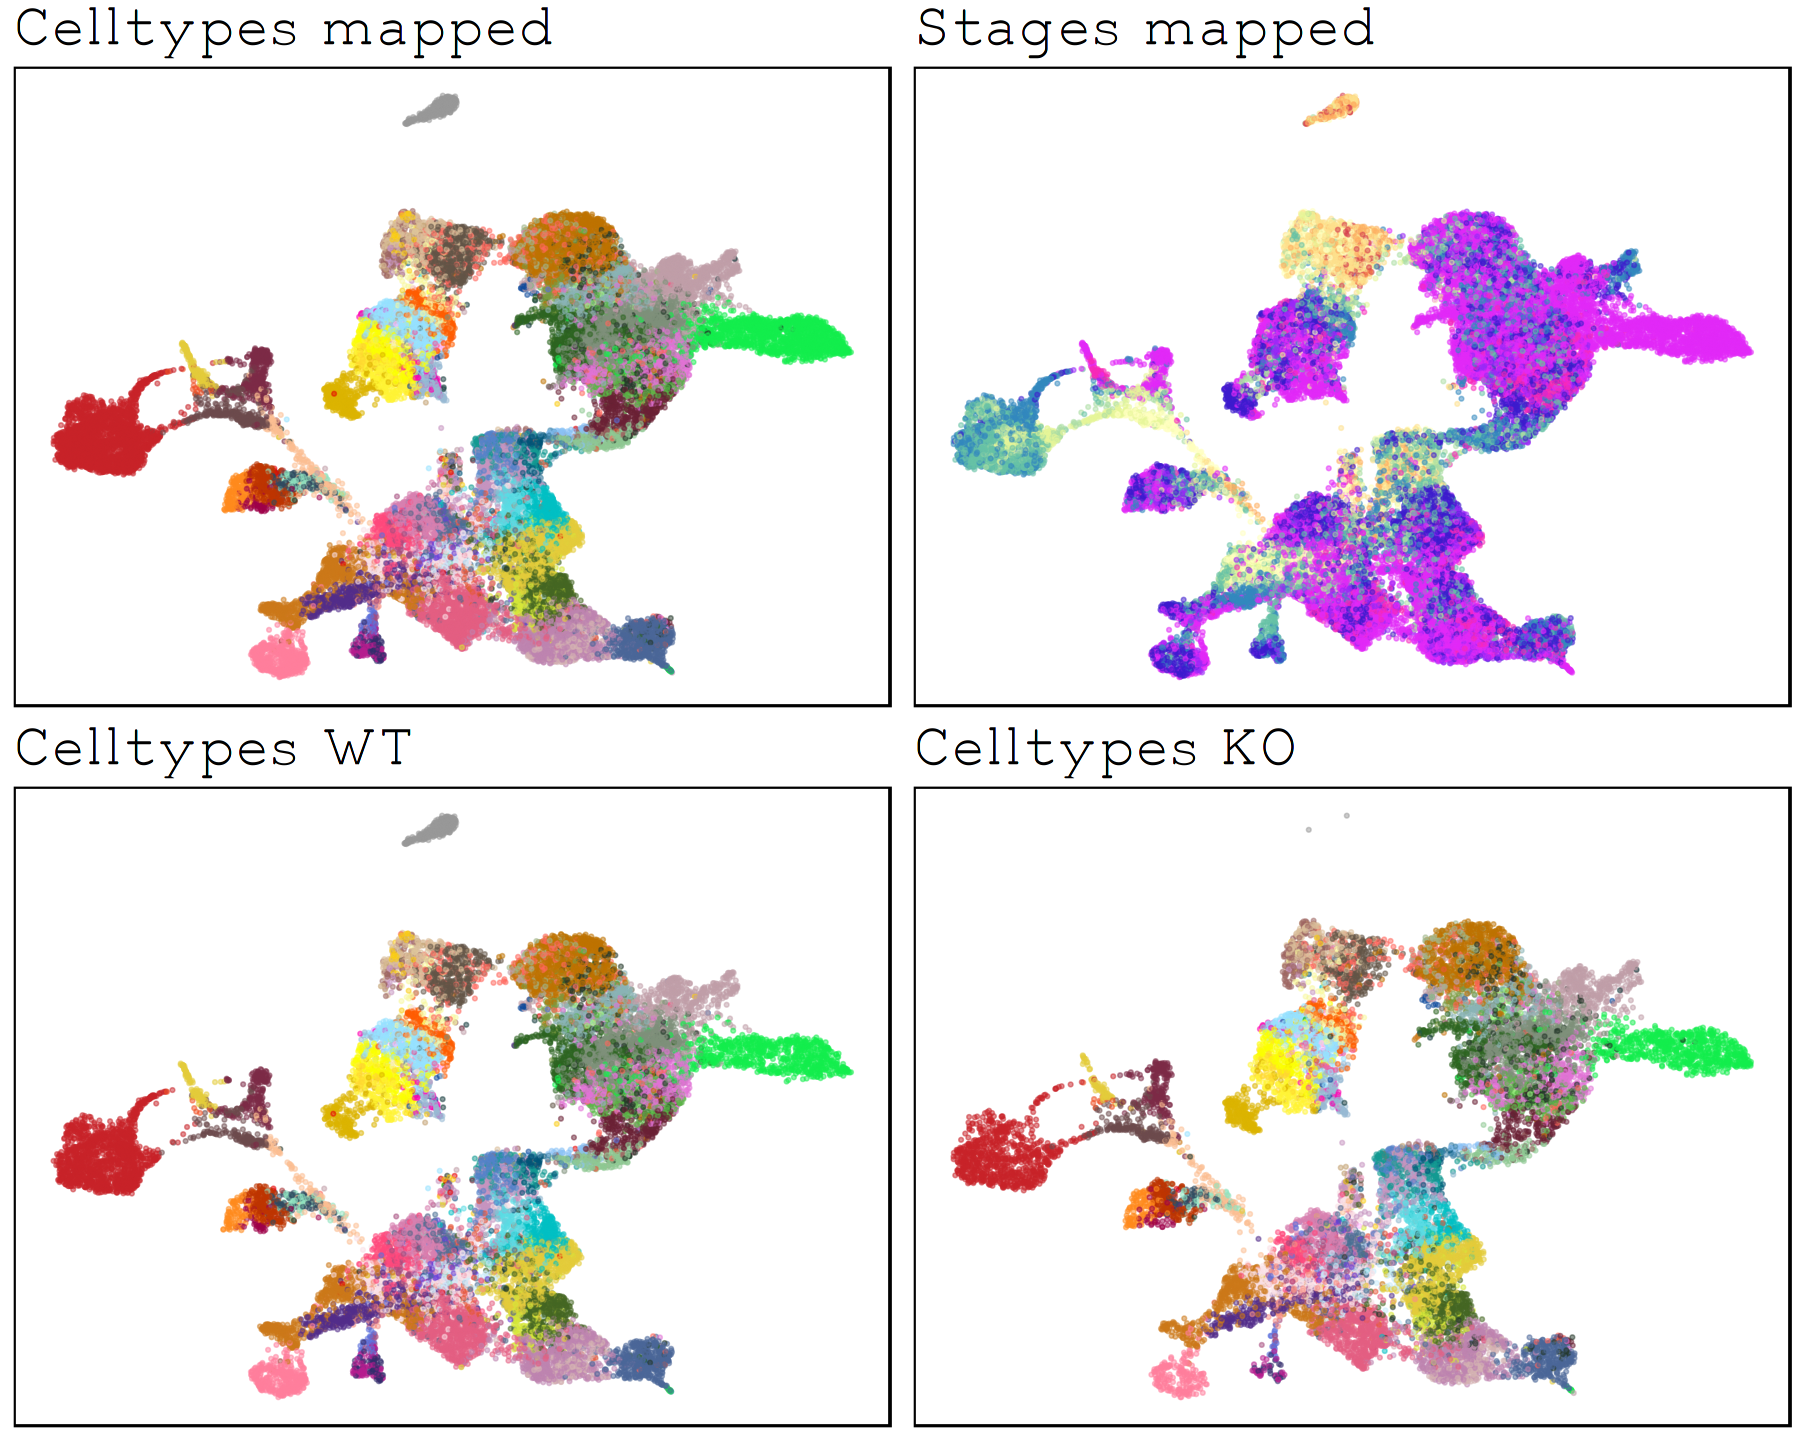

In [9]:
p1 = ggplot(meta, aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours_final, name = "celltype") +
    ggtitle('Celltypes mapped') +
    umap_theme

p2 = ggplot(meta, aes(umap_1, umap_2, col=stage.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = stage_colours_final, name = "Stage") +
    ggtitle('Stages mapped') +
    umap_theme

p3 = ggplot(meta[meta$tdTom=='negative',], aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours_final, name = "celltype") +
    ggtitle('Celltypes WT') +
    umap_theme

p4 = ggplot(meta[meta$tdTom=='positive',], aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours_final, name = "celltype") +
    ggtitle('Celltypes KO') +
    umap_theme

options(repr.plot.width=15, repr.plot.height=12)
grid.arrange(p1, p2, p3, p4, ncol = 2)
options(repr.plot.width=15, repr.plot.height=8)

# Cell-types seemed to be mapped allright, both when mapping on the atlas and when only looking at the chimera data

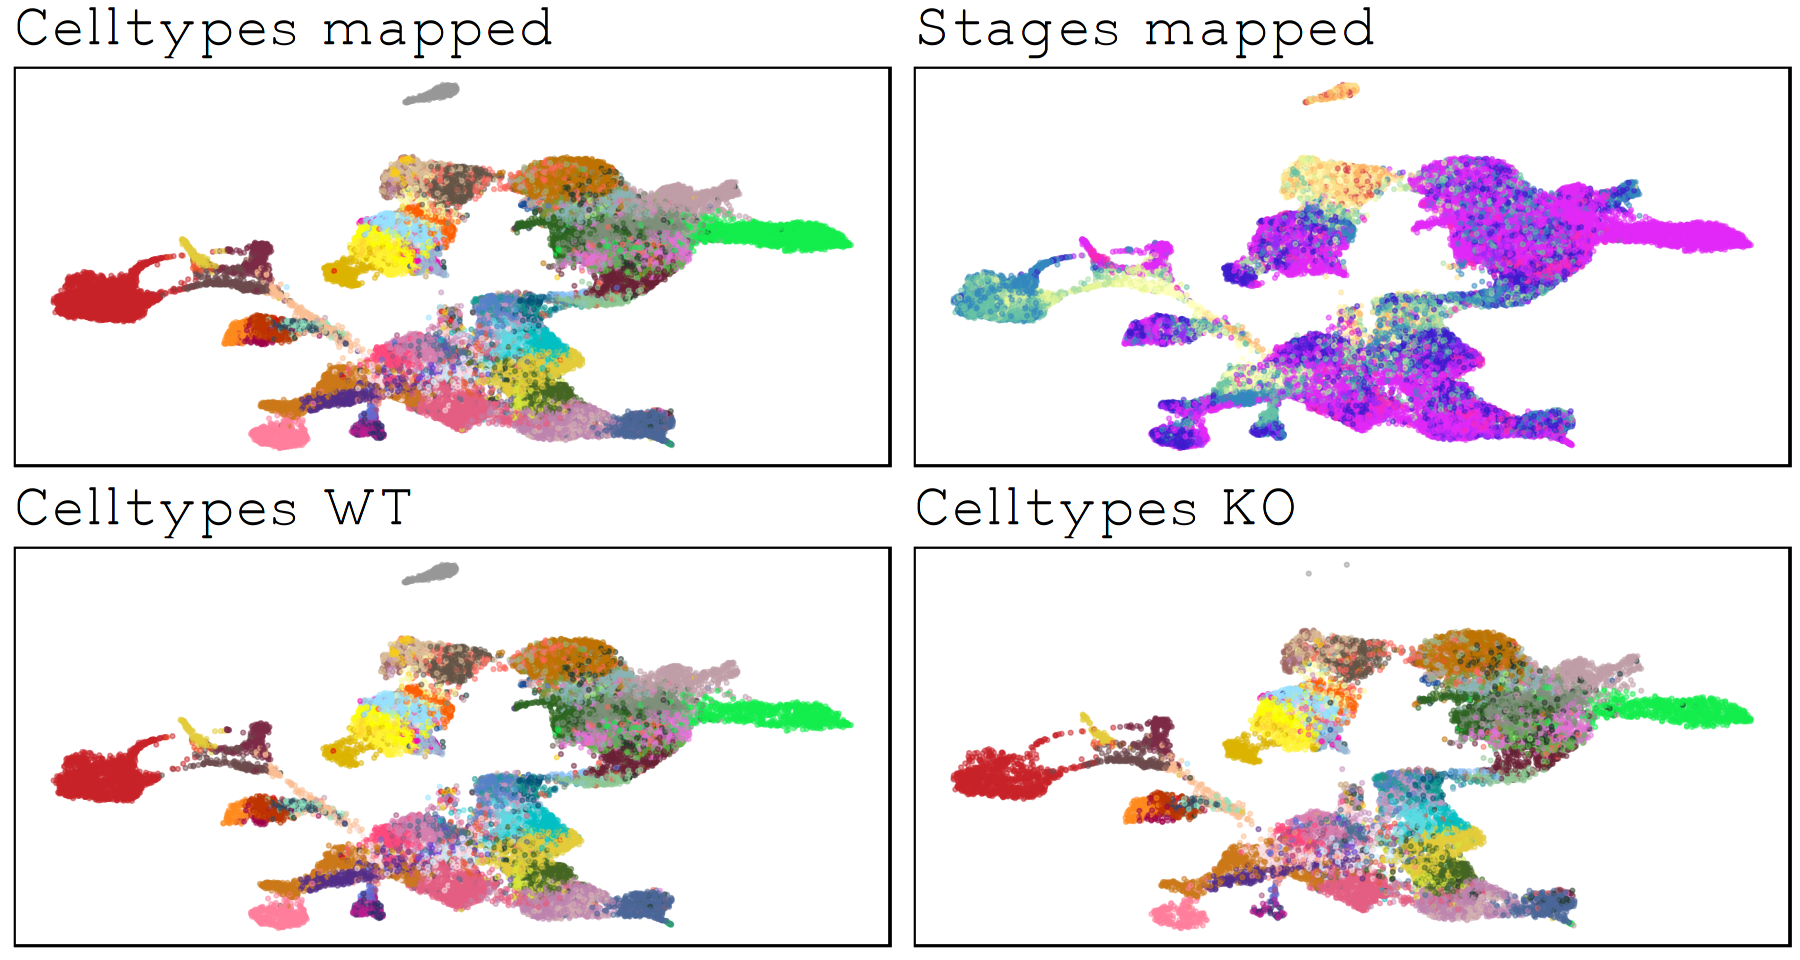

In [10]:
ggsave(paste0(out_dir, 'UMAPs_chim_only.png'), 
       plot = grid.arrange(p1, p2, p3, p4, ncol=2), 
       device = 'png',
       width = 12,
       height = 8,
       dpi = 300)

### Quantifications

In [13]:
pools = data.frame('sample' = unique(meta$sample), 'sample_name' = unique(meta$Sample_name))
pools[order(pools$sample),]

,sample,sample_name
,<int>,<chr>
1,1,MLT_31+ Tom
2,2,MLT_3+
3,3,MLT_31- Tom
4,4,MLT_3-
5,5,MLT_4+
6,6,MLT_4-
7,7,MLT_L+
8,8,MLT_1+
9,9,MLT_L-


In [51]:
embryo_pools = data.frame('sample' = 1:16, embryo_pool = c(1,2,1,2,3,3,4,5,4,5,6,7,8,6,7,8))
meta = merge(meta, embryo_pools, by='sample')

In [18]:
quant_theme = theme(text = element_text(size = 30, color='black'),
                    axis.text.x = element_text(angle = -90, hjust = 0, size = 14, color='black'),
                    legend.position = "none",
                    panel.background = element_blank(),
                    panel.grid.major = element_line(colour='grey93'), 
                    panel.grid.minor = element_line(colour='grey98'),
                    axis.title.x = element_blank(),
                    panel.border = element_rect(colour = "black", fill=NA, size=1),
                   strip.background = element_rect(fill = "white", color = "black", size = 1))


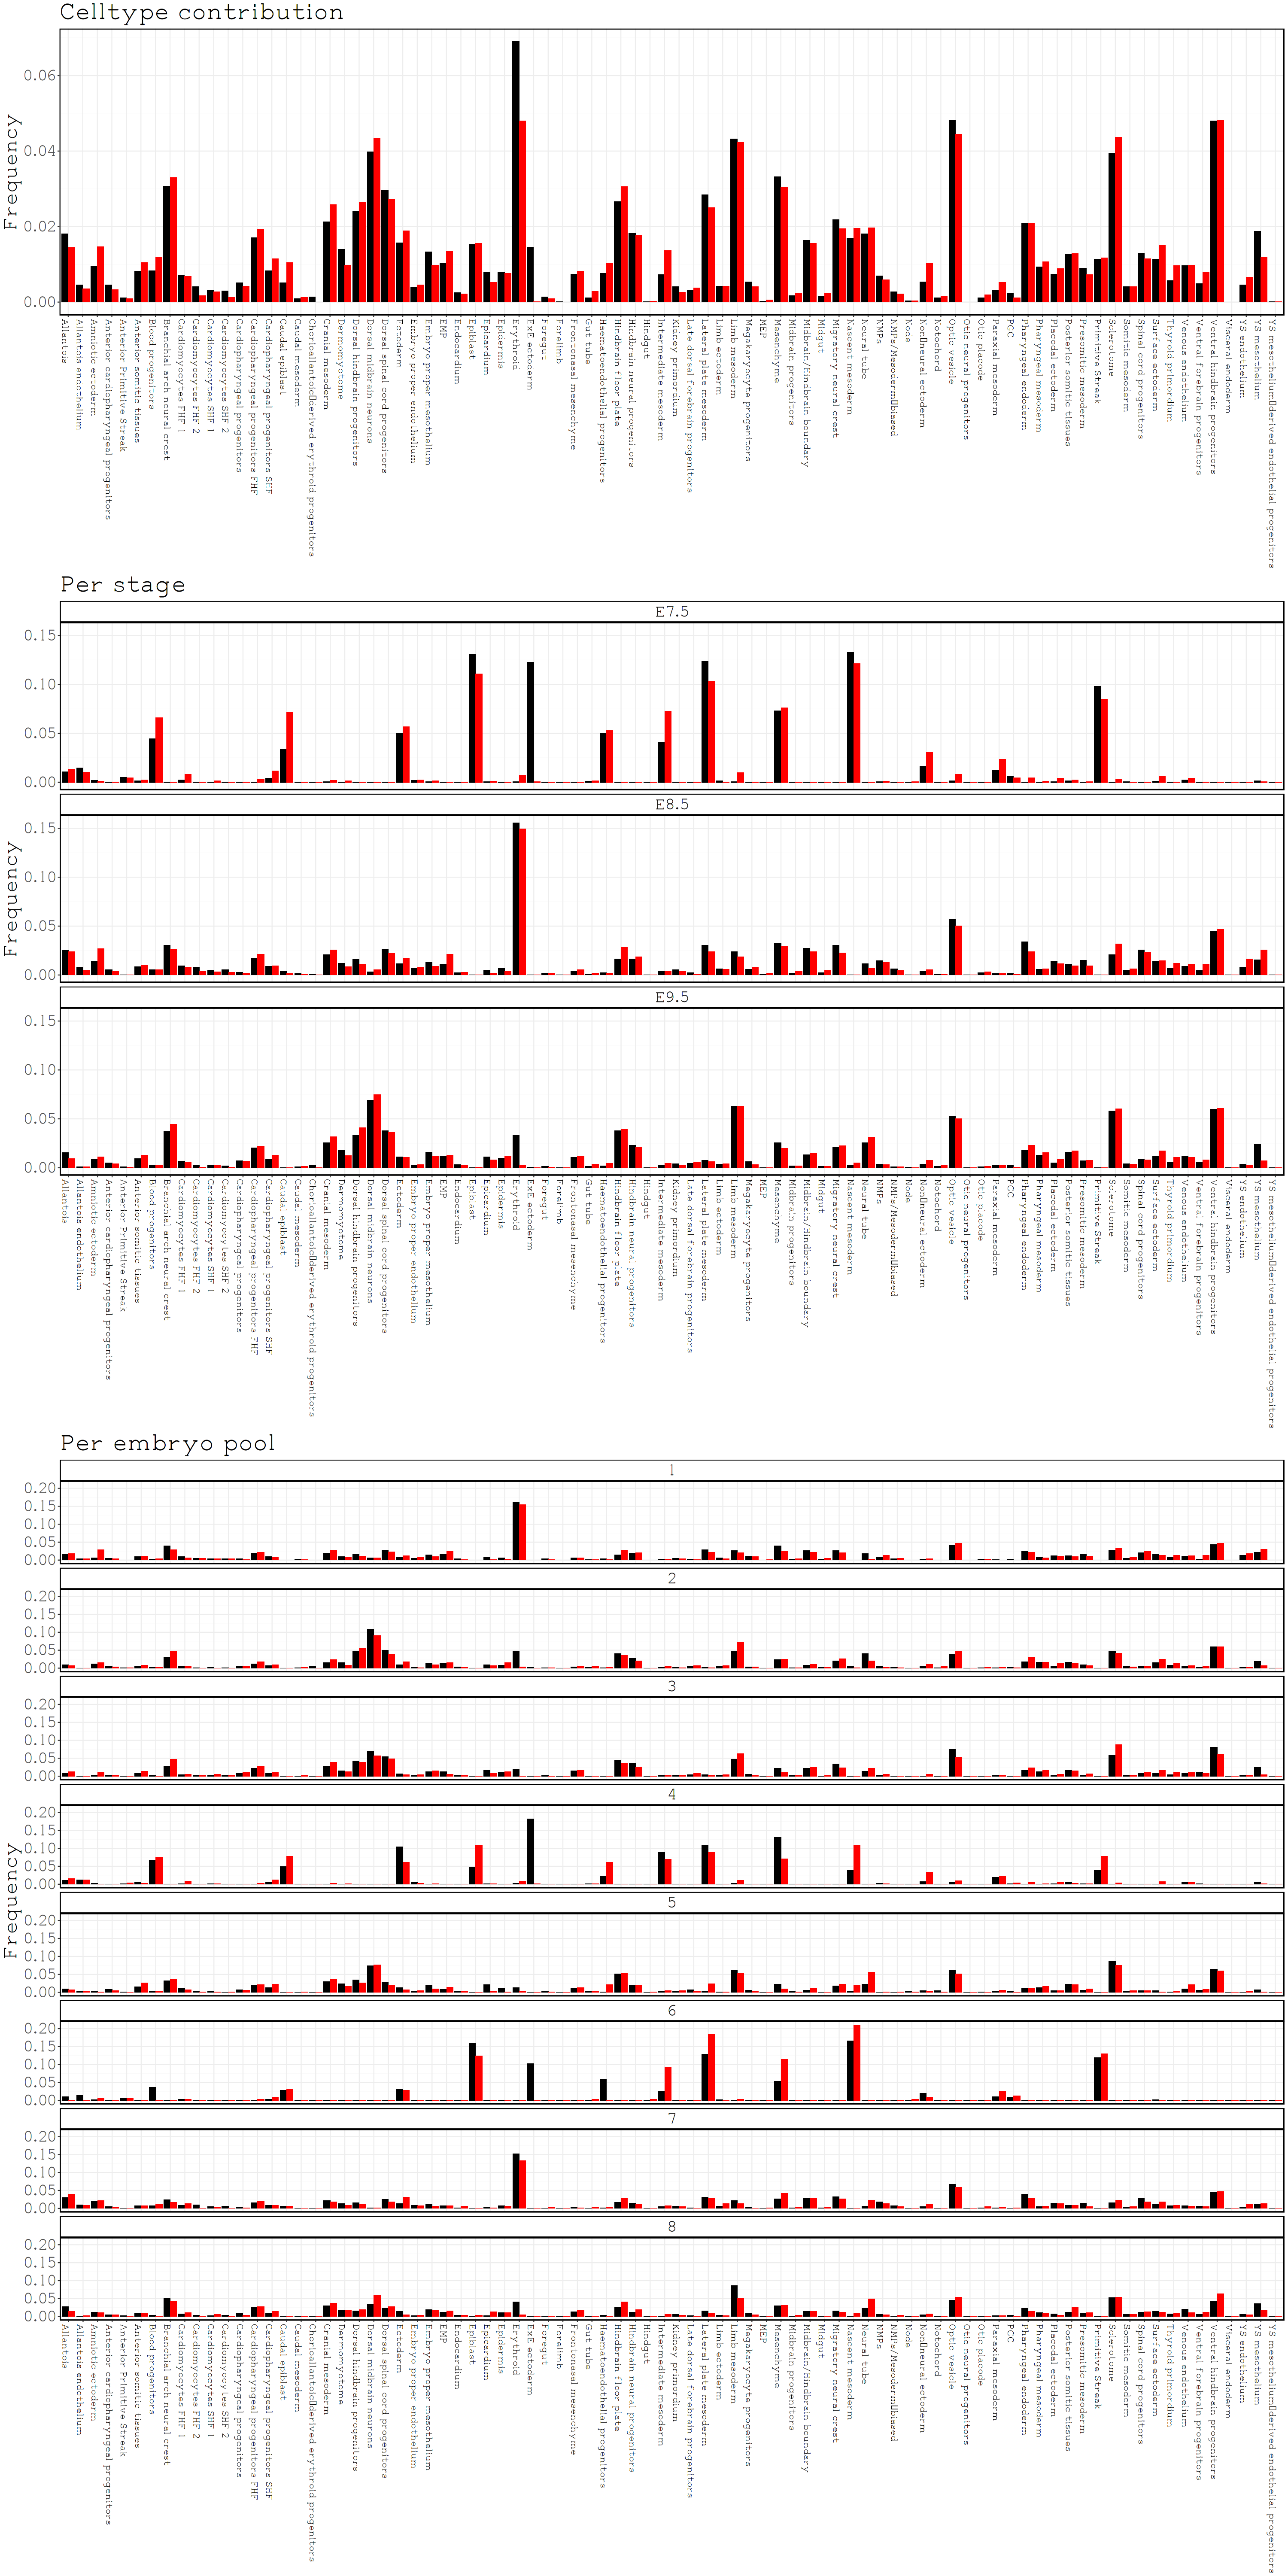

In [19]:

pdf1 = table(meta$celltype.mapped, meta$tdTom)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) +
        ggtitle('Celltype contribution') +
        ylab('Frequency') + 
        quant_theme 


pdf1 = table(meta$celltype.mapped, meta$tdTom, meta$stage)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) +
        ggtitle('Per stage') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 1) +
        quant_theme 

pdf1 = table(meta$celltype.mapped, meta$tdTom, meta$embryo_pool)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p3 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) +
        ggtitle('Per embryo pool') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 1) +
        quant_theme 

options(repr.plot.width=25, repr.plot.height=50)
grid.arrange(p1, p2, p3, ncol = 1, heights = c(2,3,4))
options(repr.plot.width=15, repr.plot.height=8)

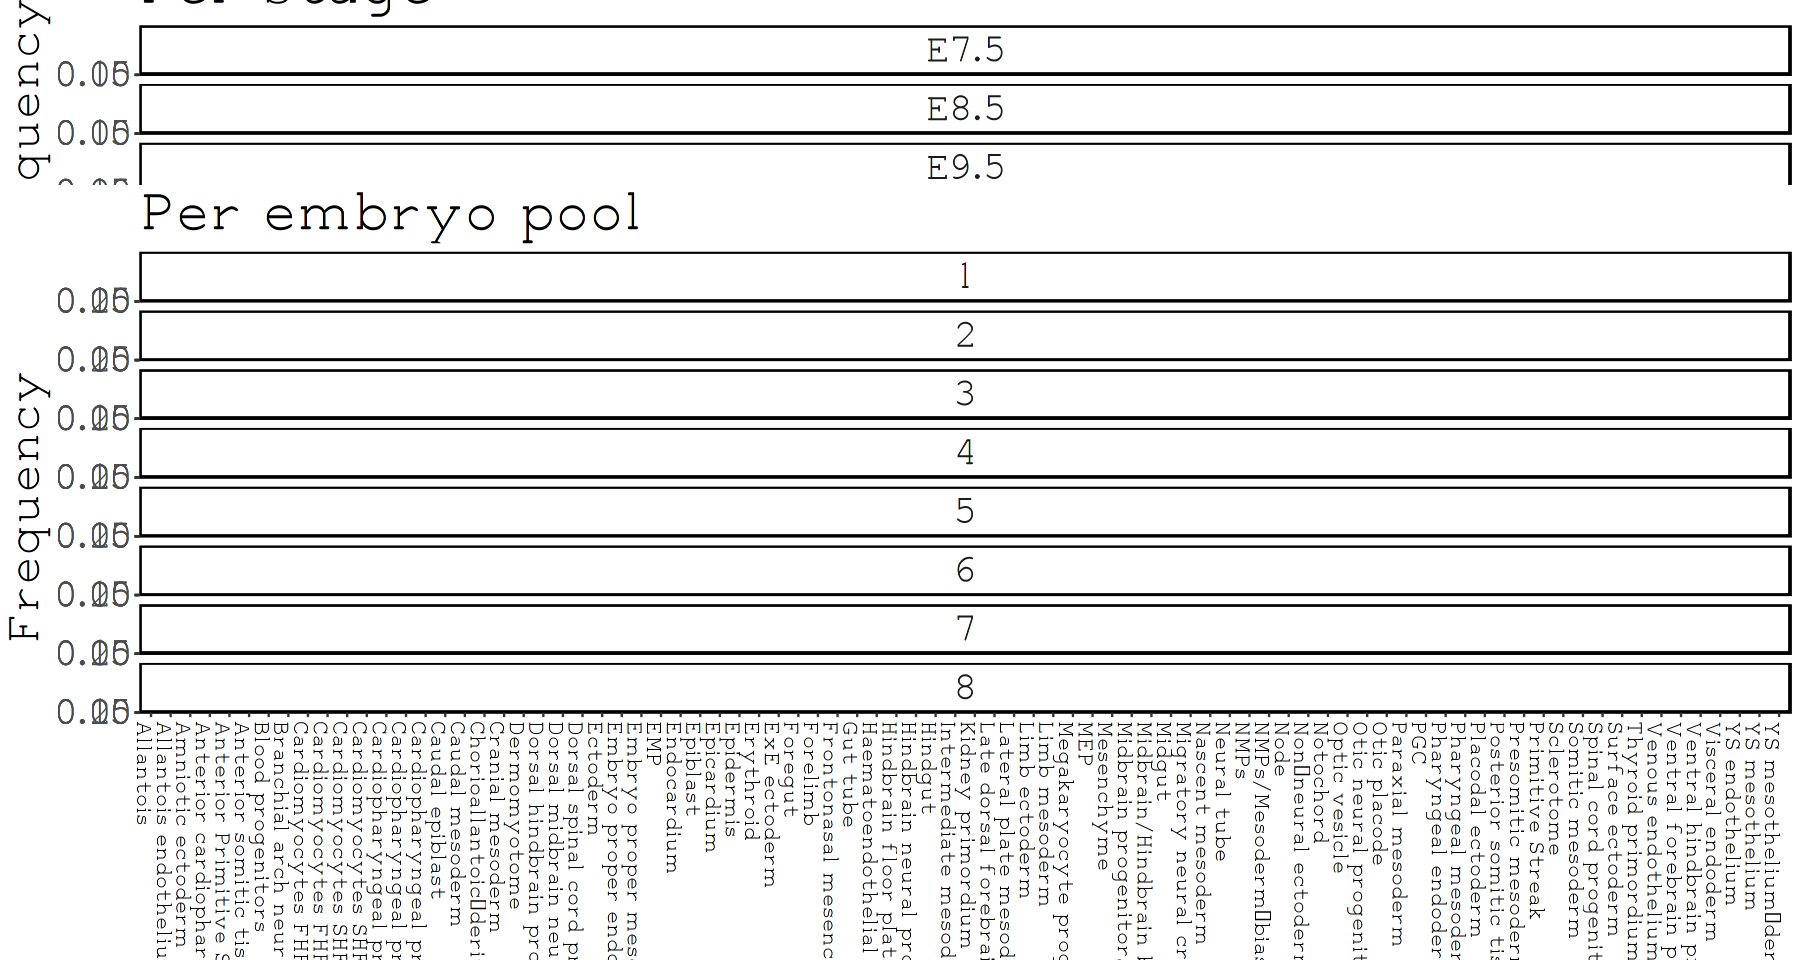

In [20]:
ggsave(paste(out_dir, 'celltype_distribution.pdf'), 
      grid.arrange(p1, p2, p3, ncol = 1, heights = c(2,3,4)),
       device='pdf', width=20, height=35)

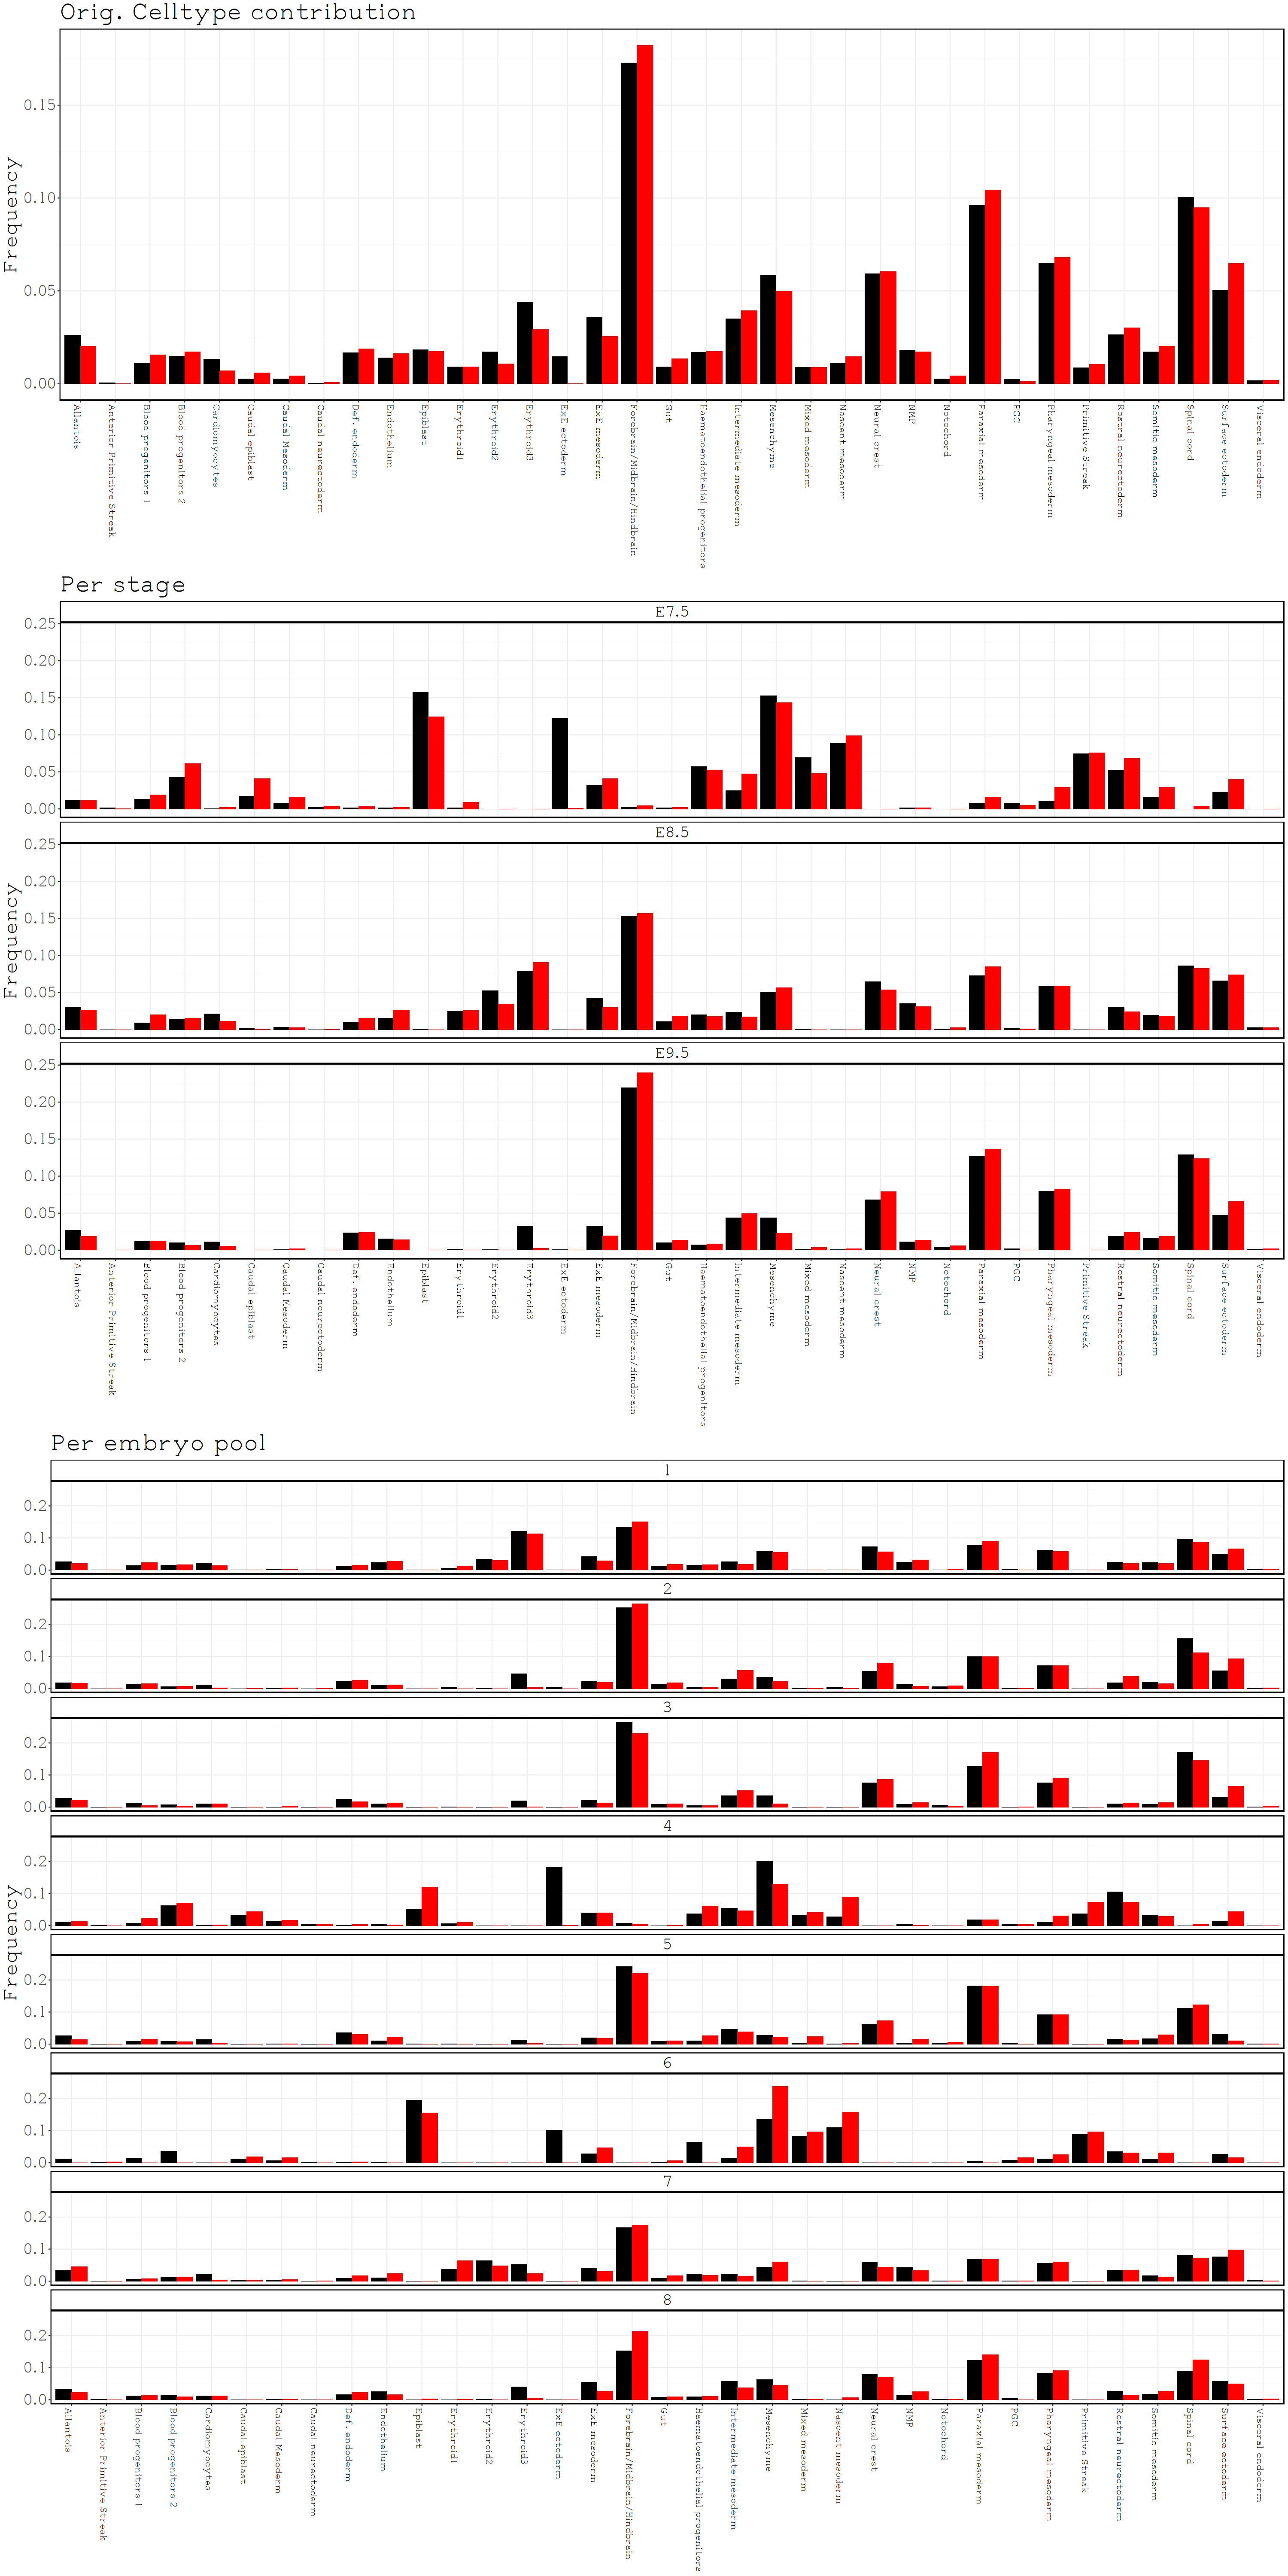

In [52]:
pdf1 = table(meta$celltype_original.mapped, meta$tdTom)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype_original.mapped)[order(unique(meta$celltype_original.mapped))]) +
        ggtitle('Orig. Celltype contribution') +
        ylab('Frequency') + 
        quant_theme 

pdf1 = table(meta$celltype_original.mapped, meta$tdTom, meta$stage)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype_original.mapped)[order(unique(meta$celltype_original.mapped))]) +
        ggtitle('Per stage') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 1) +
        quant_theme 

pdf1 = table(meta$celltype_original.mapped, meta$tdTom, meta$embryo_pool)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p3 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype_original.mapped)[order(unique(meta$celltype_original.mapped))]) +
        ggtitle('Per embryo pool') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 1) +
        quant_theme 



options(repr.plot.width=25, repr.plot.height=50)
       grid.arrange(p1, p2, p3, ncol = 1, heights = c(2,3,4))
options(repr.plot.width=15, repr.plot.height=8)

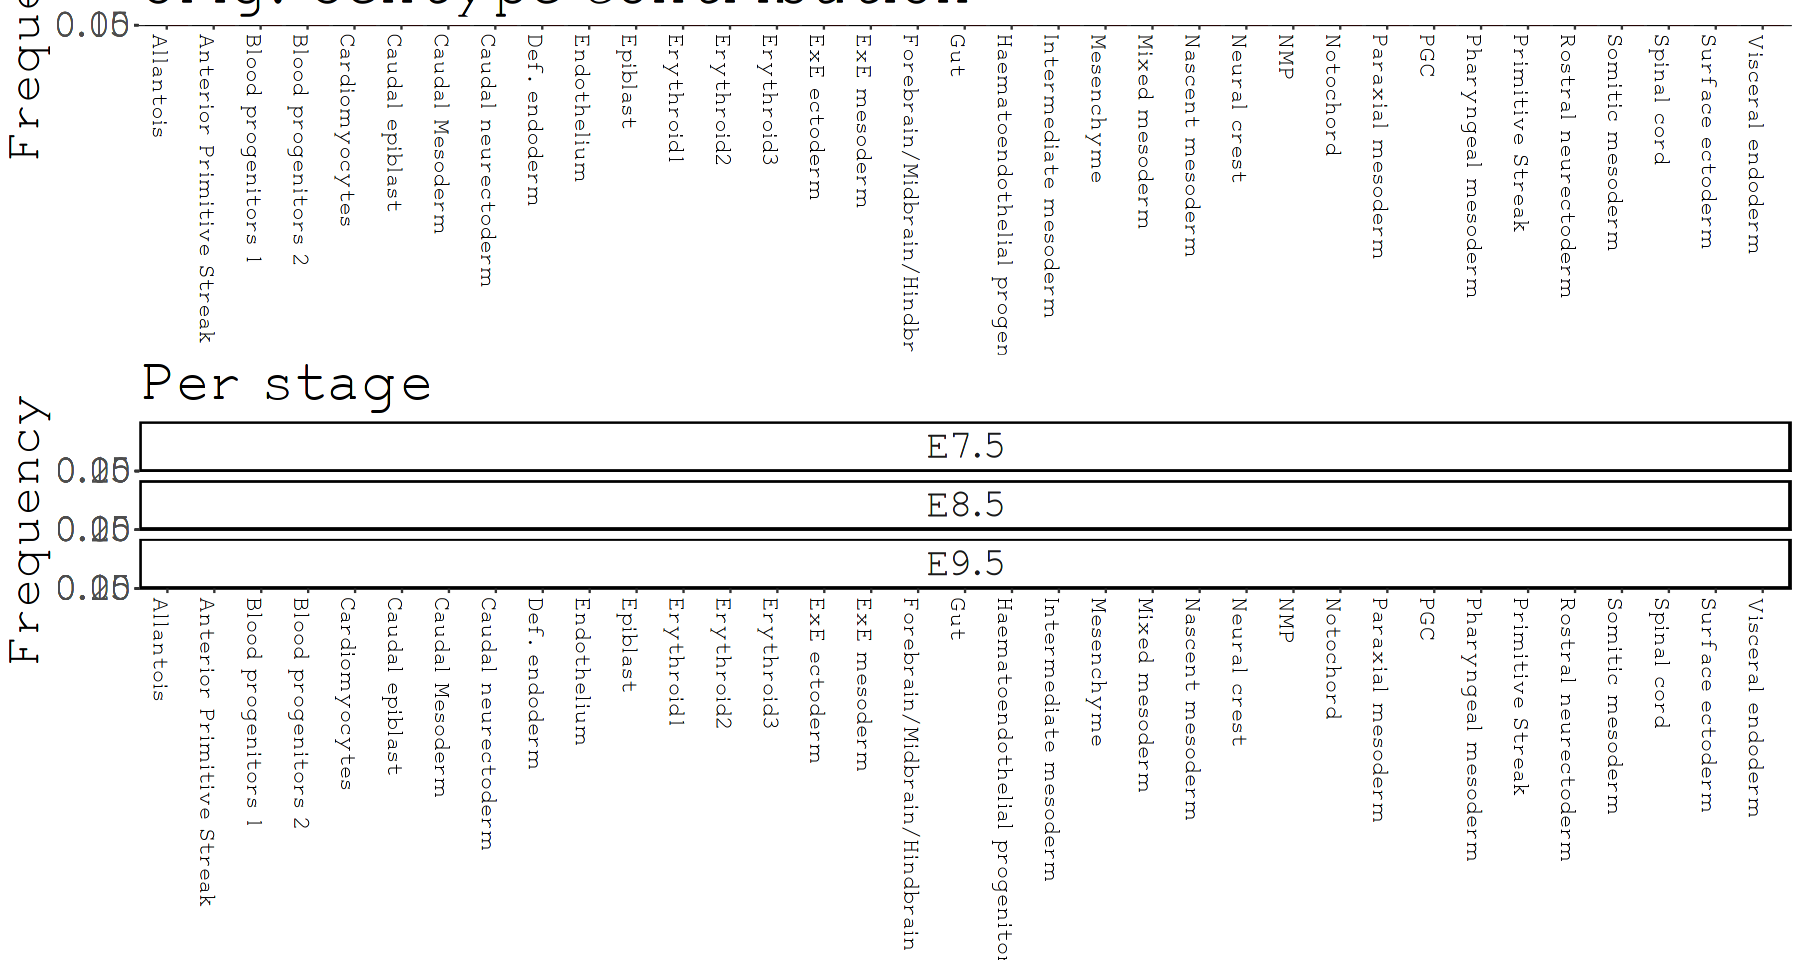

In [53]:
ggsave(paste(out_dir, 'celltype_original_distribution.pdf'), 
       grid.arrange(p1, p2, ncol = 1, heights = c(2,3)),
       device='pdf', width=15, height=15)

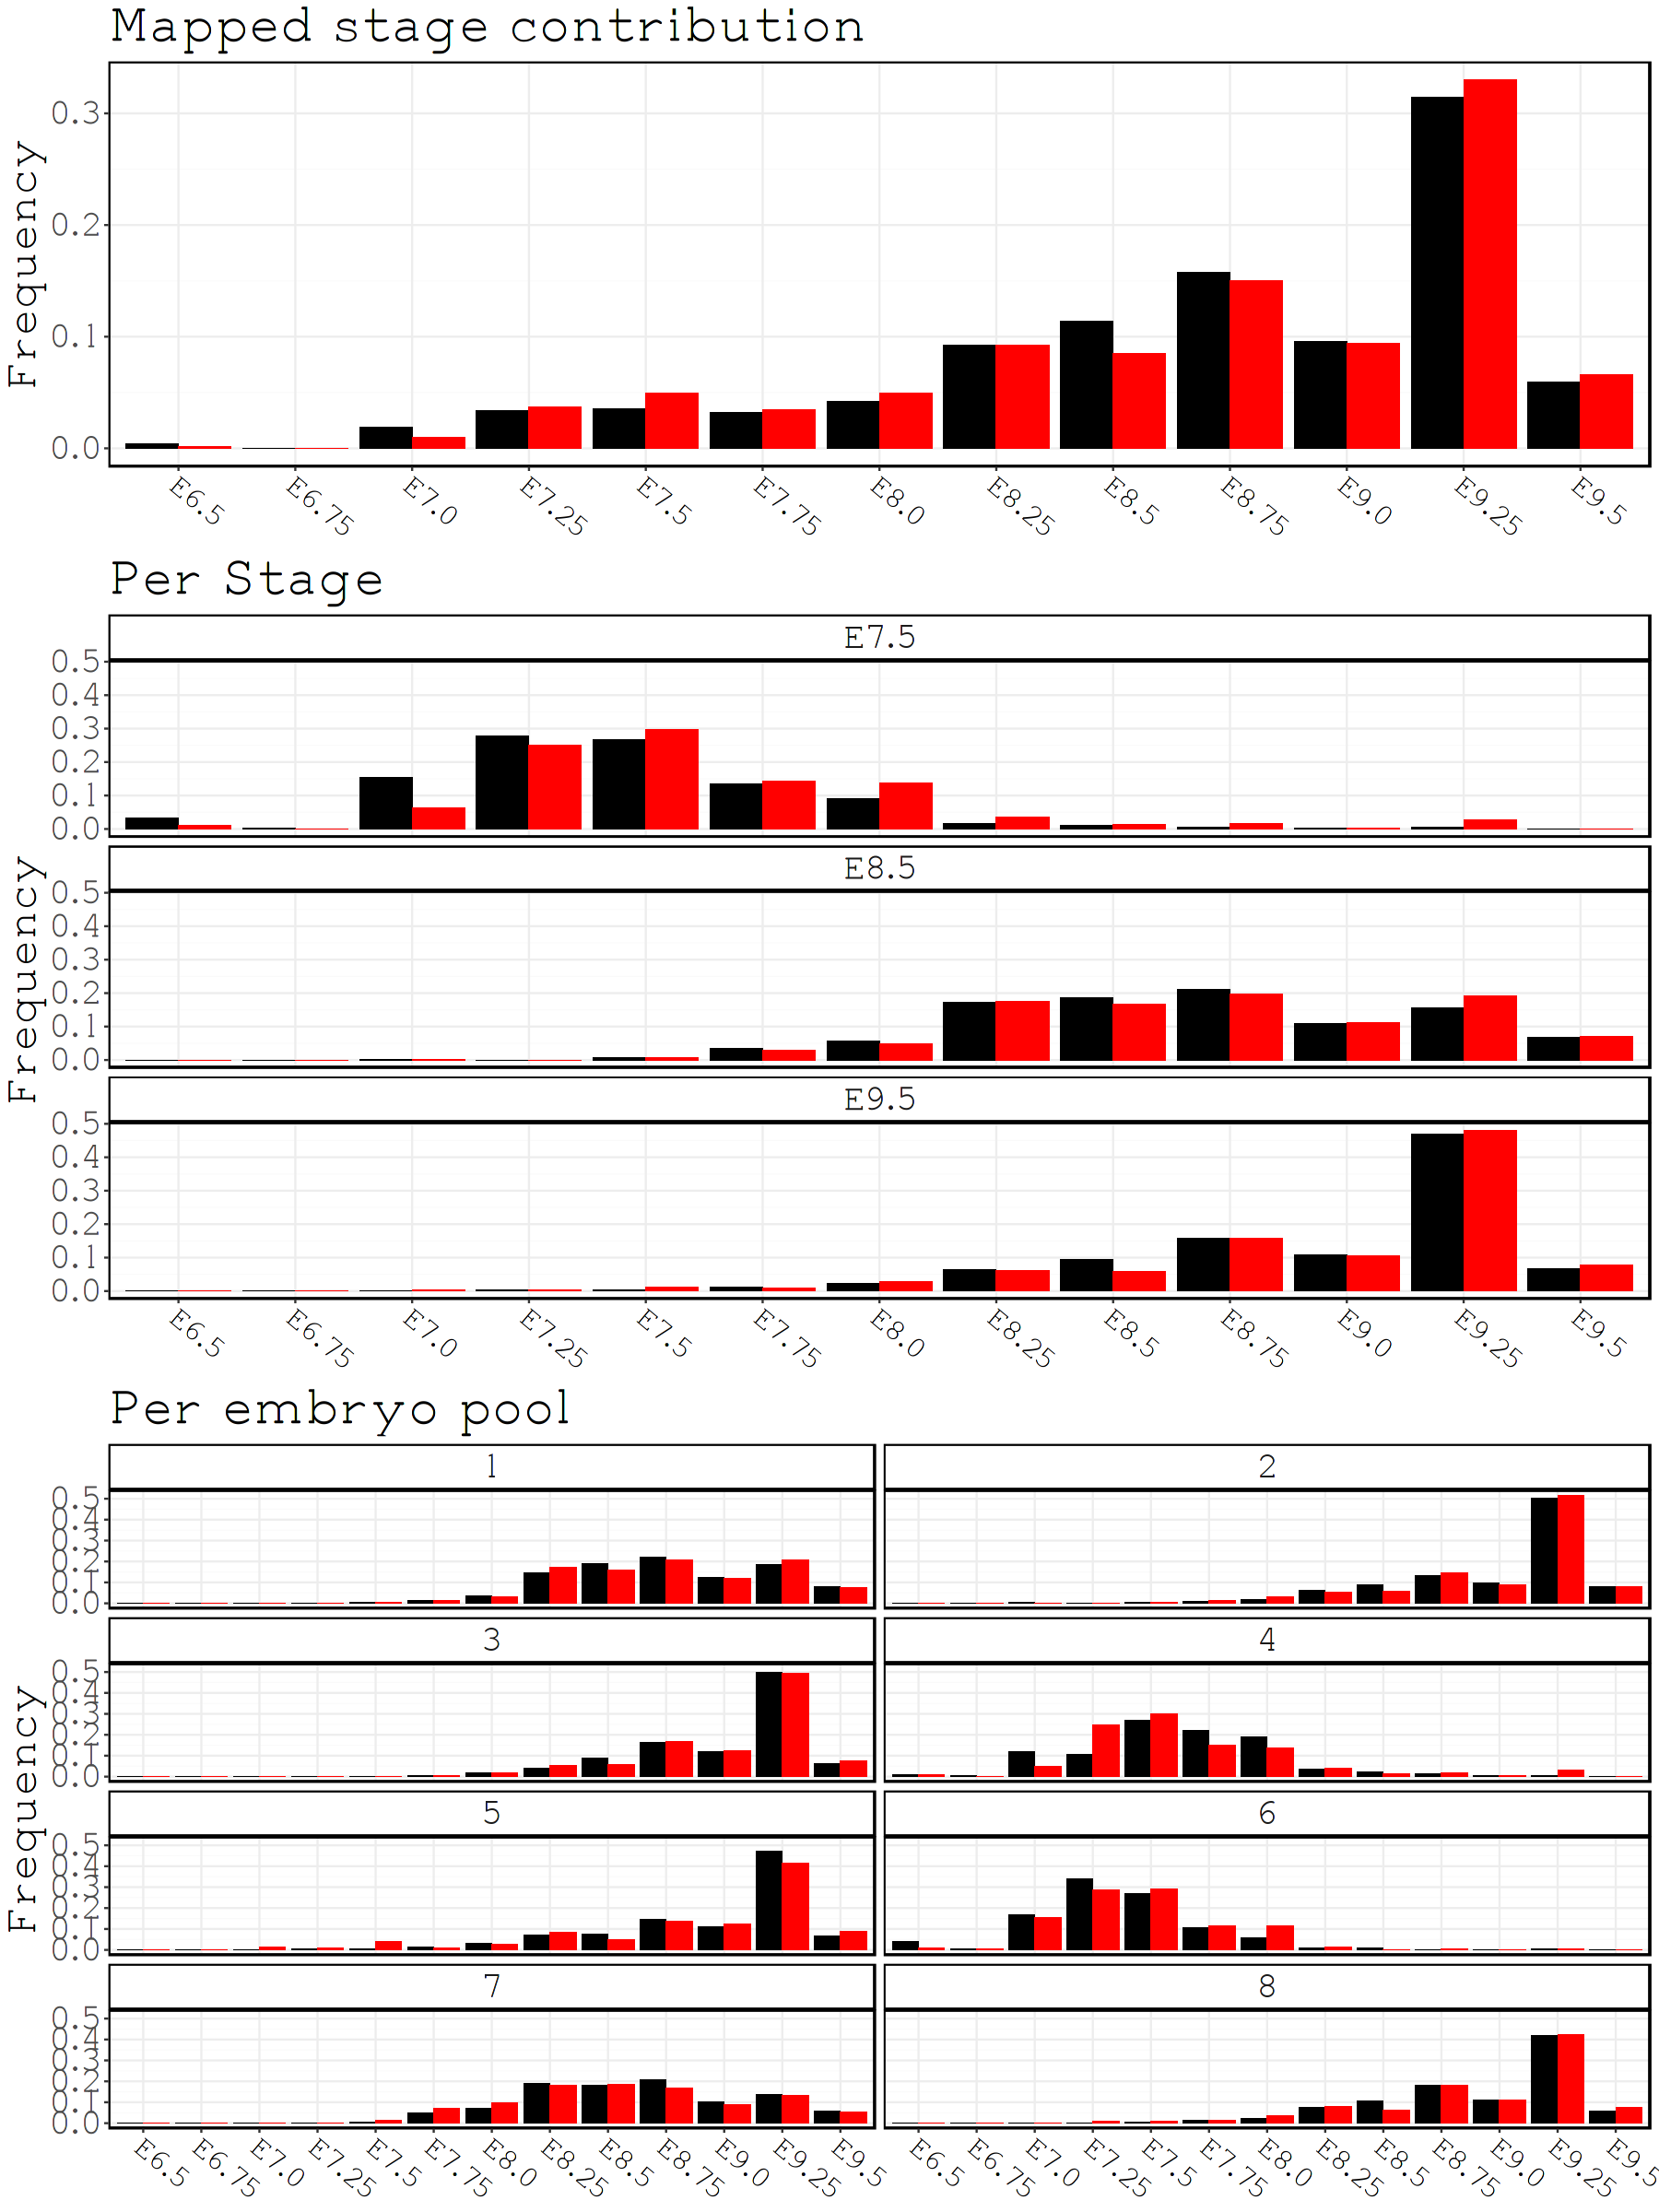

In [23]:
pdf1 = table(meta$stage.mapped, meta$tdTom)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Mapped stage contribution') +
        ylab('Frequency') + 
        quant_theme + theme(axis.text.x = element_text(angle = -40, hjust = 0, size = 20, color='black'))


pdf1 = table(meta$stage.mapped, meta$tdTom, meta$stage)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Per Stage') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol=1) +
        quant_theme + theme(axis.text.x = element_text(angle = -40, hjust = 0, size = 20, color='black'))


pdf1 = table(meta$stage.mapped, meta$tdTom, meta$embryo_pool)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p3 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Per embryo pool') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol=2) +
        quant_theme + theme(axis.text.x = element_text(angle = -40, hjust = 0, size = 20, color='black'))

options(repr.plot.width=15, repr.plot.height=20)
grid.arrange(p1, p2, p3, ncol = 1, heights = c(2,3,3))
options(repr.plot.width=15, repr.plot.height=8)

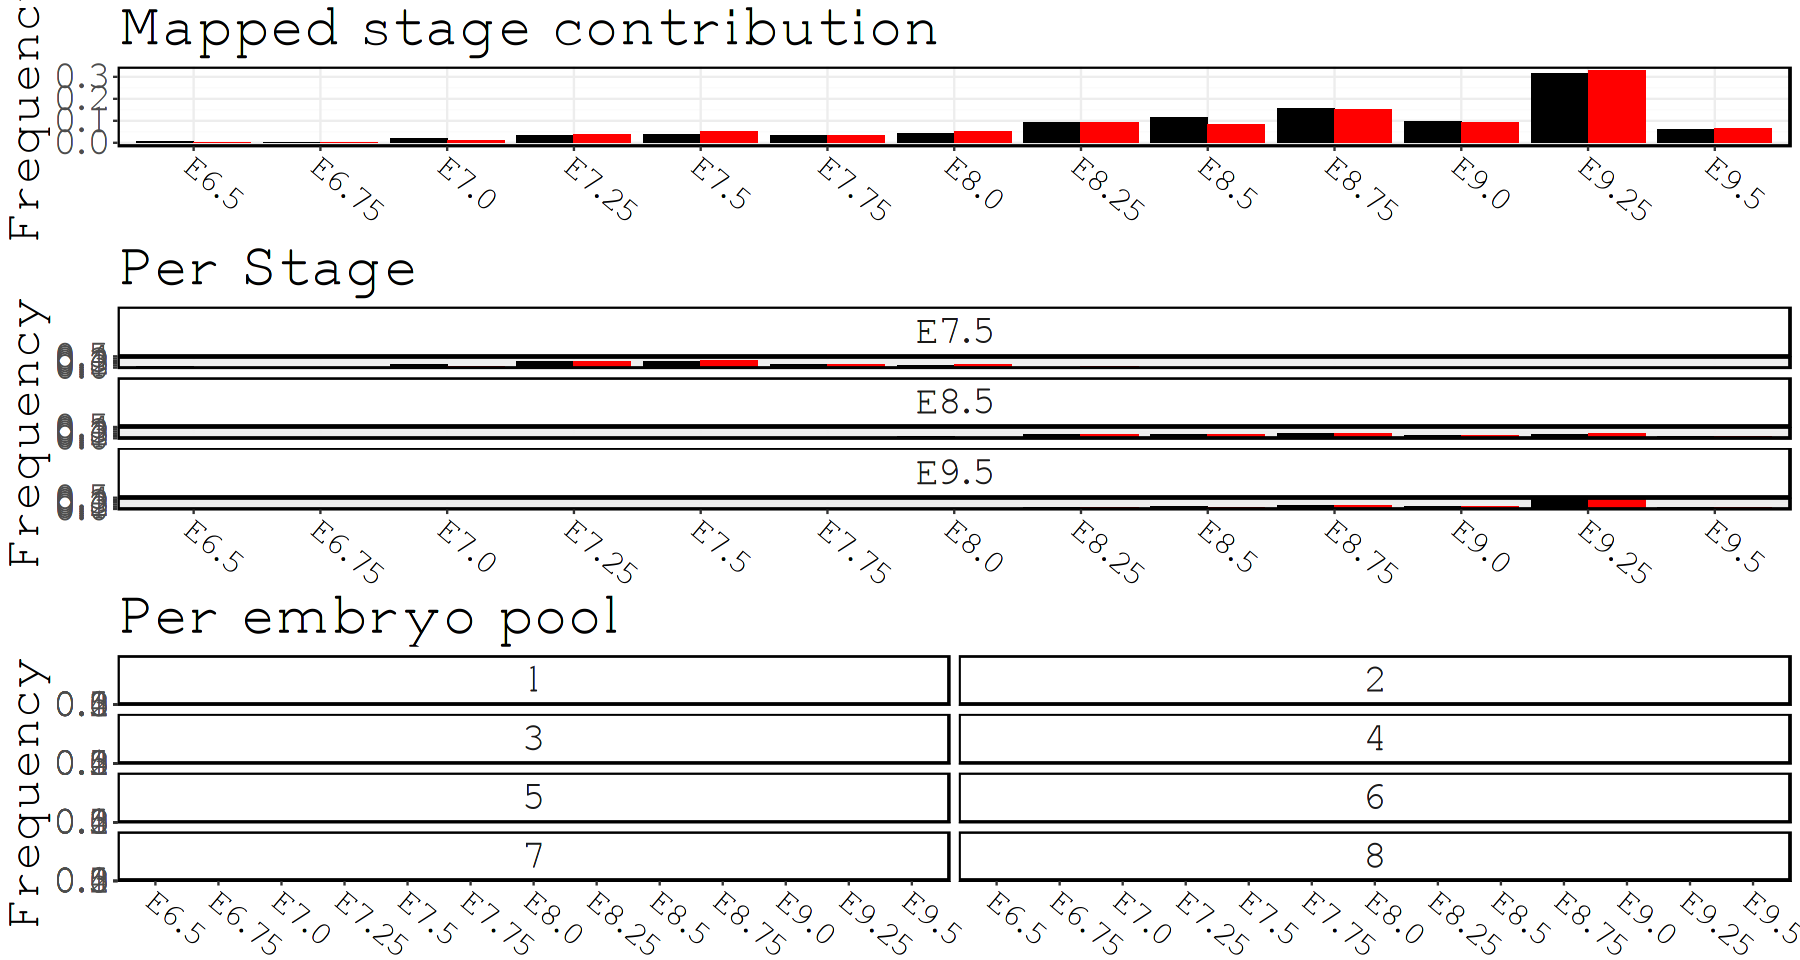

In [24]:
ggsave(paste0(out_dir, 'stage_distributions.pdf'), 
        grid.arrange(p1, p2, p3, ncol = 1, heights = c(2,3,3)),
       device = 'pdf',
       width = 15,
       height = 25)

Warning message:
“Removed 13 rows containing missing values (geom_bar).”


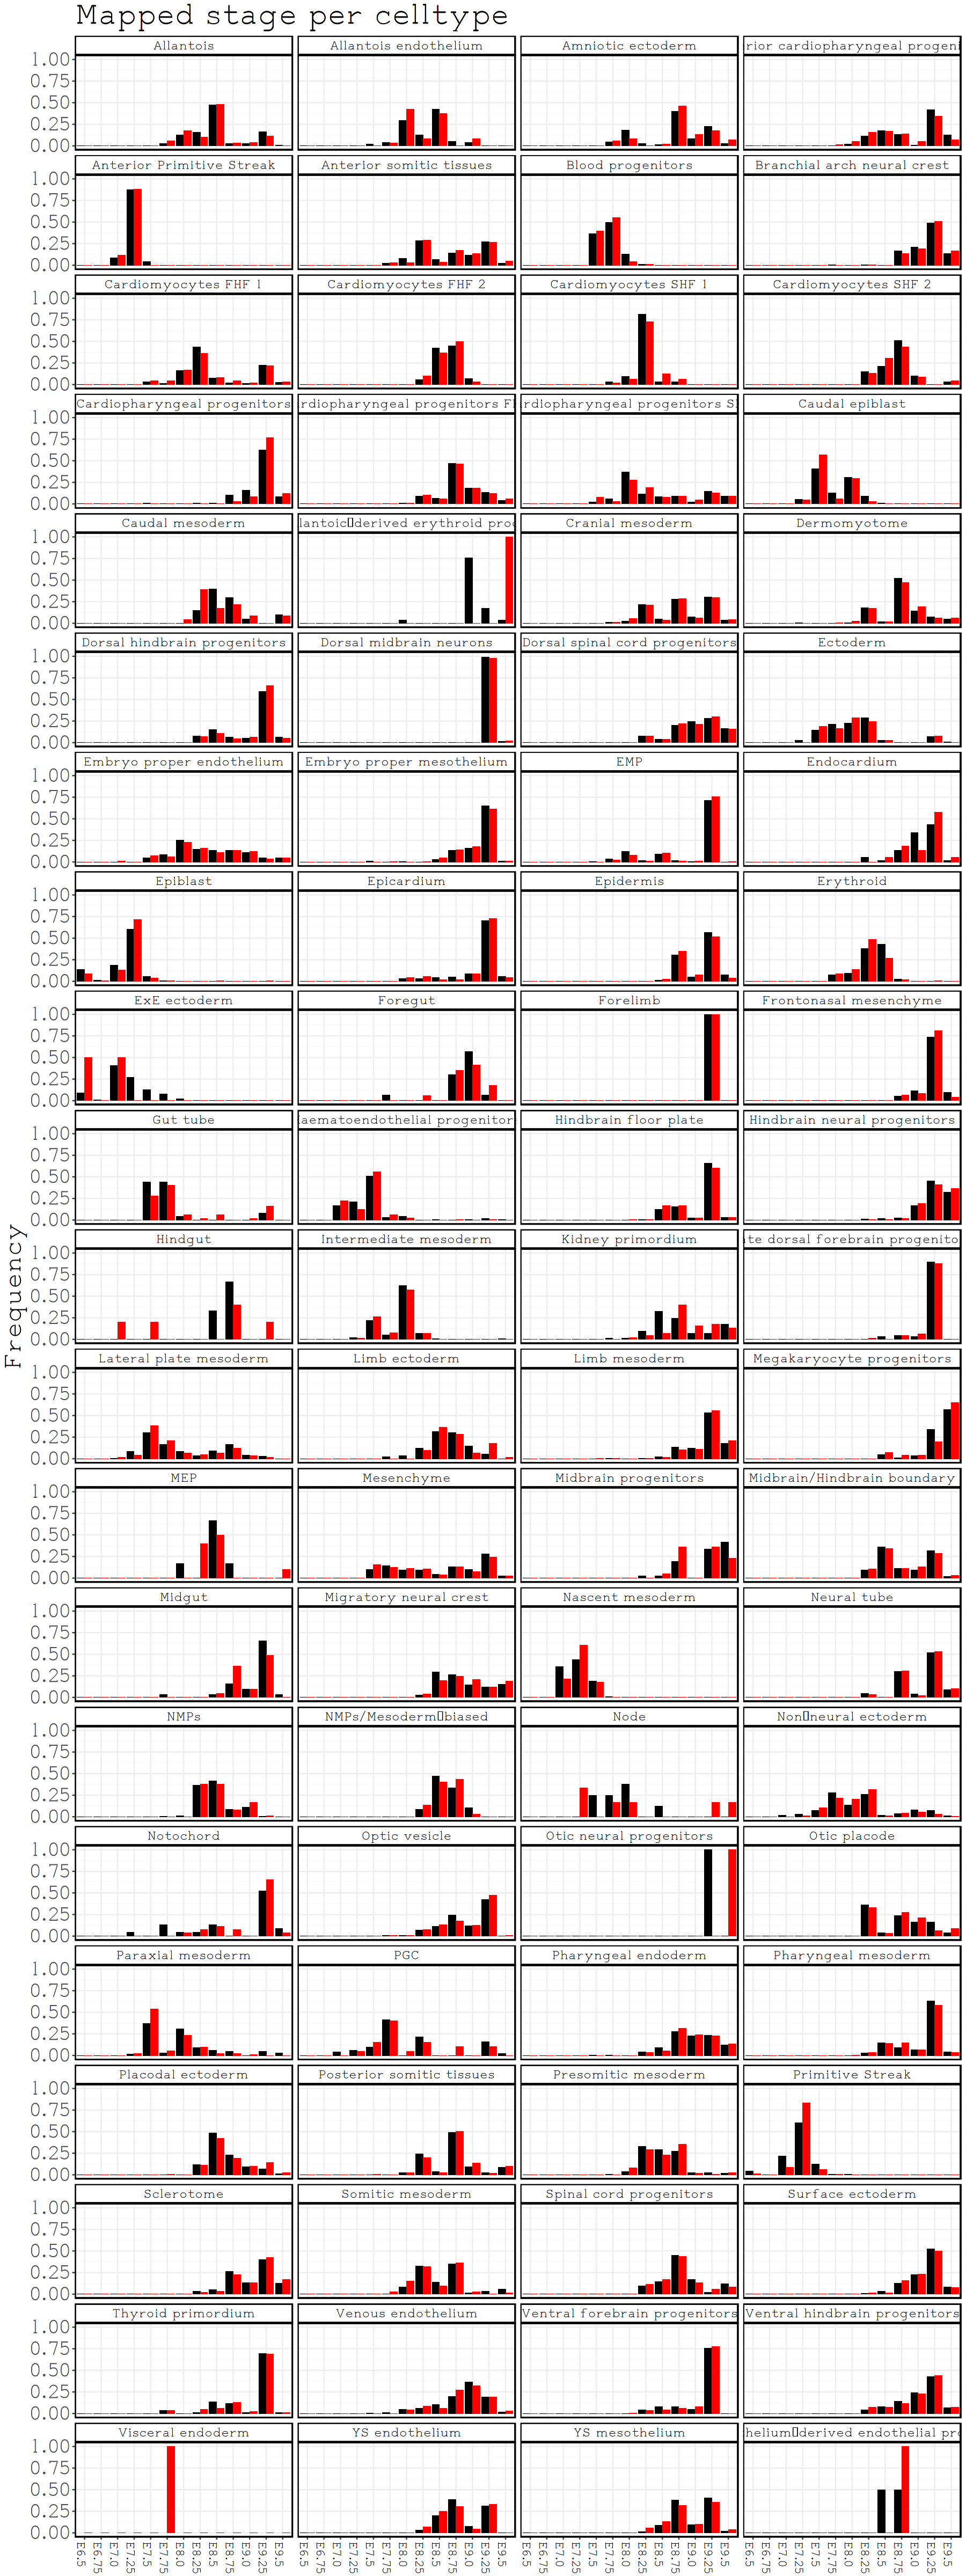

In [25]:
pdf1 = table(meta$stage.mapped, meta$tdTom, meta$celltype.mapped)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Mapped stage per celltype') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 4) +
        quant_theme + theme(strip.text = element_text(size = 15, color='black'))
options(repr.plot.width=15, repr.plot.height=40)
p1

In [26]:
ggsave(paste0(out_dir, 'stage_per_celltype.pdf'), 
       plot = p1, 
       device = 'pdf',
       width = 15,
       height = 40)

Warning message:
“Removed 13 rows containing missing values (geom_bar).”


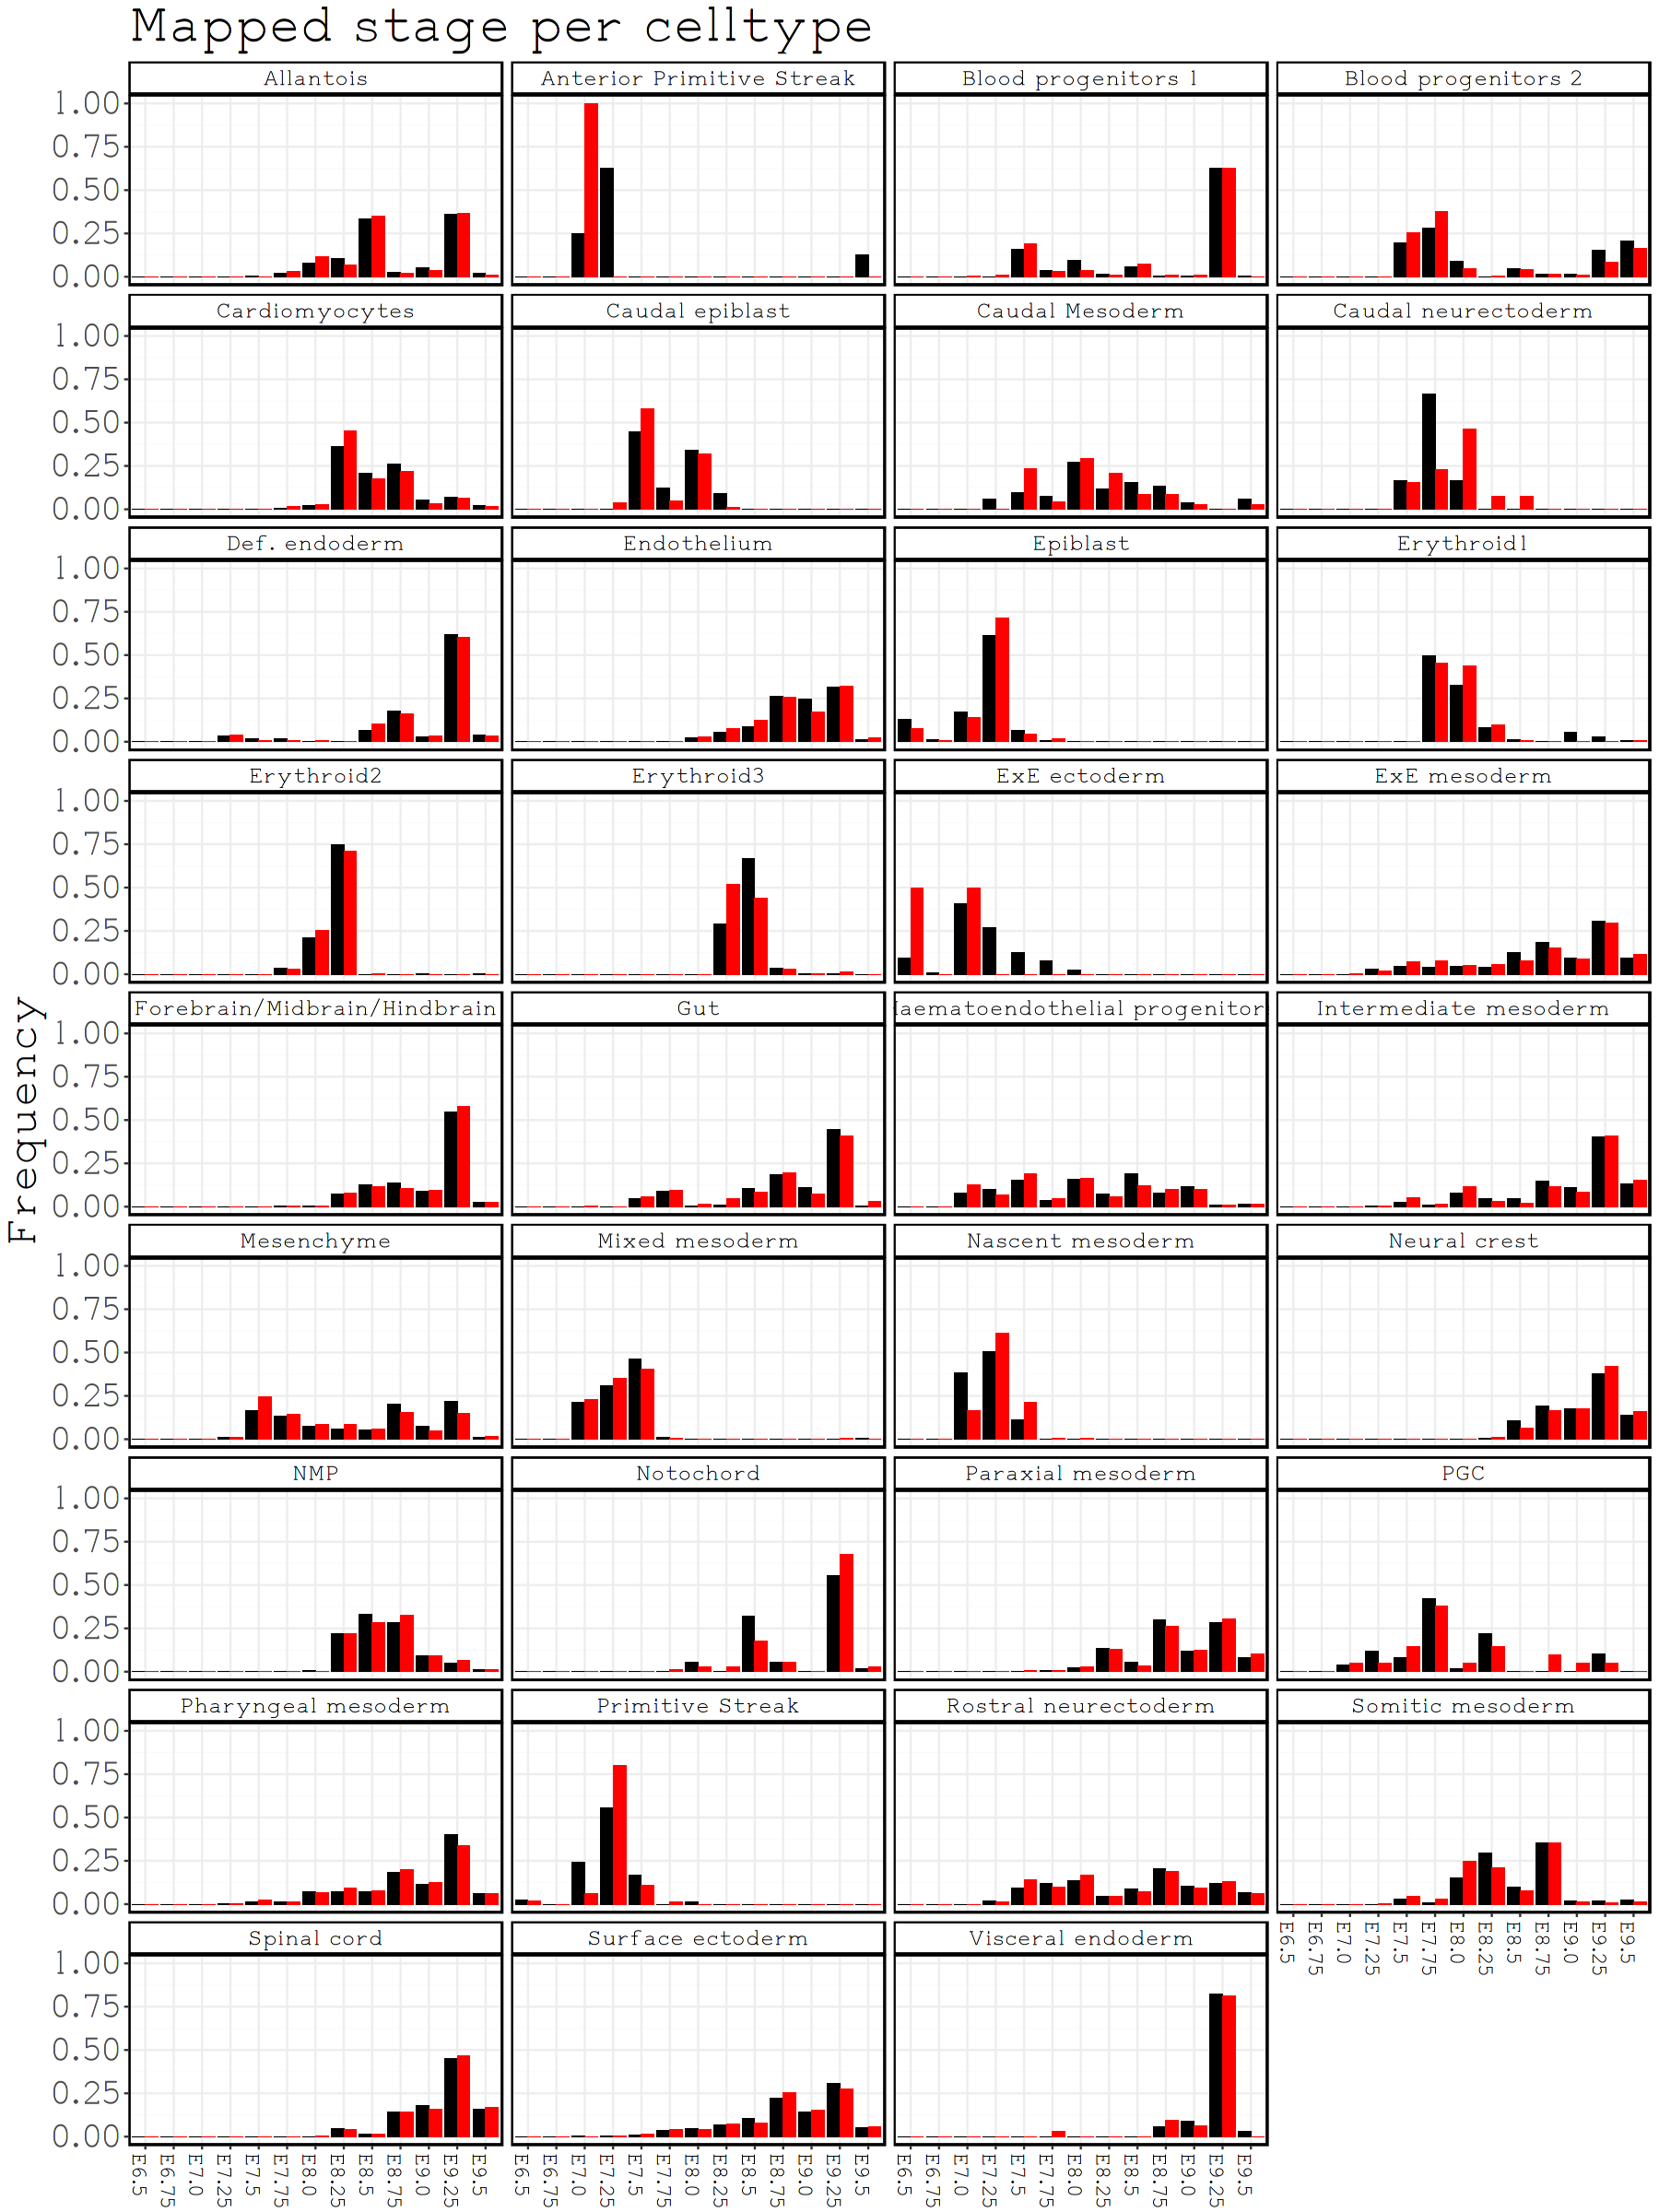

In [27]:
pdf1 = table(meta$stage.mapped, meta$tdTom, meta$celltype_original.mapped)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Mapped stage per celltype') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 4) +
        quant_theme + theme(strip.text = element_text(size = 15, color='black'))
options(repr.plot.width=15, repr.plot.height=20)
p1

In [28]:
ggsave(paste0(out_dir, 'stage_per_celltype_original.pdf'), 
       plot = p1, 
       device = 'pdf',
       width = 15,
       height = 20)

In [29]:
head(meta)

,sample,closest.cell,cell,Sample_name,barcode,batch,batch_name,tdTom,index,stage,...,louvain_cluster,celltype.mapped,celltype_original.mapped,stage.mapped,celltype.score,celltype_original.score,cellstage.score,umapX.mapped,umapY.mapped,embryo_pool
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,...,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,cell_130410,cell_1,MLT_31+ Tom,AAACCCAAGATGTTCC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,1,E8.5,...,20,Erythroid,Erythroid3,E8.5,1.0000000,1.0000000,0.8333333,8.894147,-4.379566,1
2,1,ext_cell_65004,cell_2,MLT_31+ Tom,AAACCCATCAGACCTA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,2,E8.5,...,11,Mesenchyme,Mesenchyme,E9.0,1.0000000,1.0000000,0.4666667,12.375899,-3.950081,1
3,1,cell_69799,cell_3,MLT_31+ Tom,AAACGAACAATGTTGC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,3,E8.5,...,17,Anterior somitic tissues,Paraxial mesoderm,E8.25,0.9666667,1.0000000,0.5000000,19.298925,10.329799,1
4,1,cell_93369,cell_4,MLT_31+ Tom,AAACGAACACACCAGC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,4,E8.5,...,20,Erythroid,Erythroid2,E8.25,1.0000000,0.5333333,0.8000000,5.619335,-5.187152,1
5,1,cell_136074,cell_5,MLT_31+ Tom,AAACGAAGTGATAGTA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,5,E8.5,...,20,Erythroid,Erythroid3,E8.5,1.0000000,1.0000000,0.8666667,8.613827,-5.146487,1
6,1,ext_cell_338973,cell_6,MLT_31+ Tom,AAACGAAGTTAAGACA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,6,E8.5,...,7,Dorsal spinal cord progenitors,Spinal cord,E9.25,0.3000000,0.7333333,0.5666667,13.251280,17.152754,1


In [30]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] gridExtra_2.3               dplyr_1.0.7.9000           
 [3] data.table_1.14.2           reticulate_1.18            
 [5] scran_1.18.1                knitr_1.30                 
 [7] reshape2_1.4.4              scater_1.18.3              
 [9] SingleCellExperiment_1.12.0 

In [43]:
load_data(remove_doublets=TRUE, remove_stripped=TRUE)
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

In [44]:
tdtom_count = logcounts(sce)[nrow(counts(sce)),]

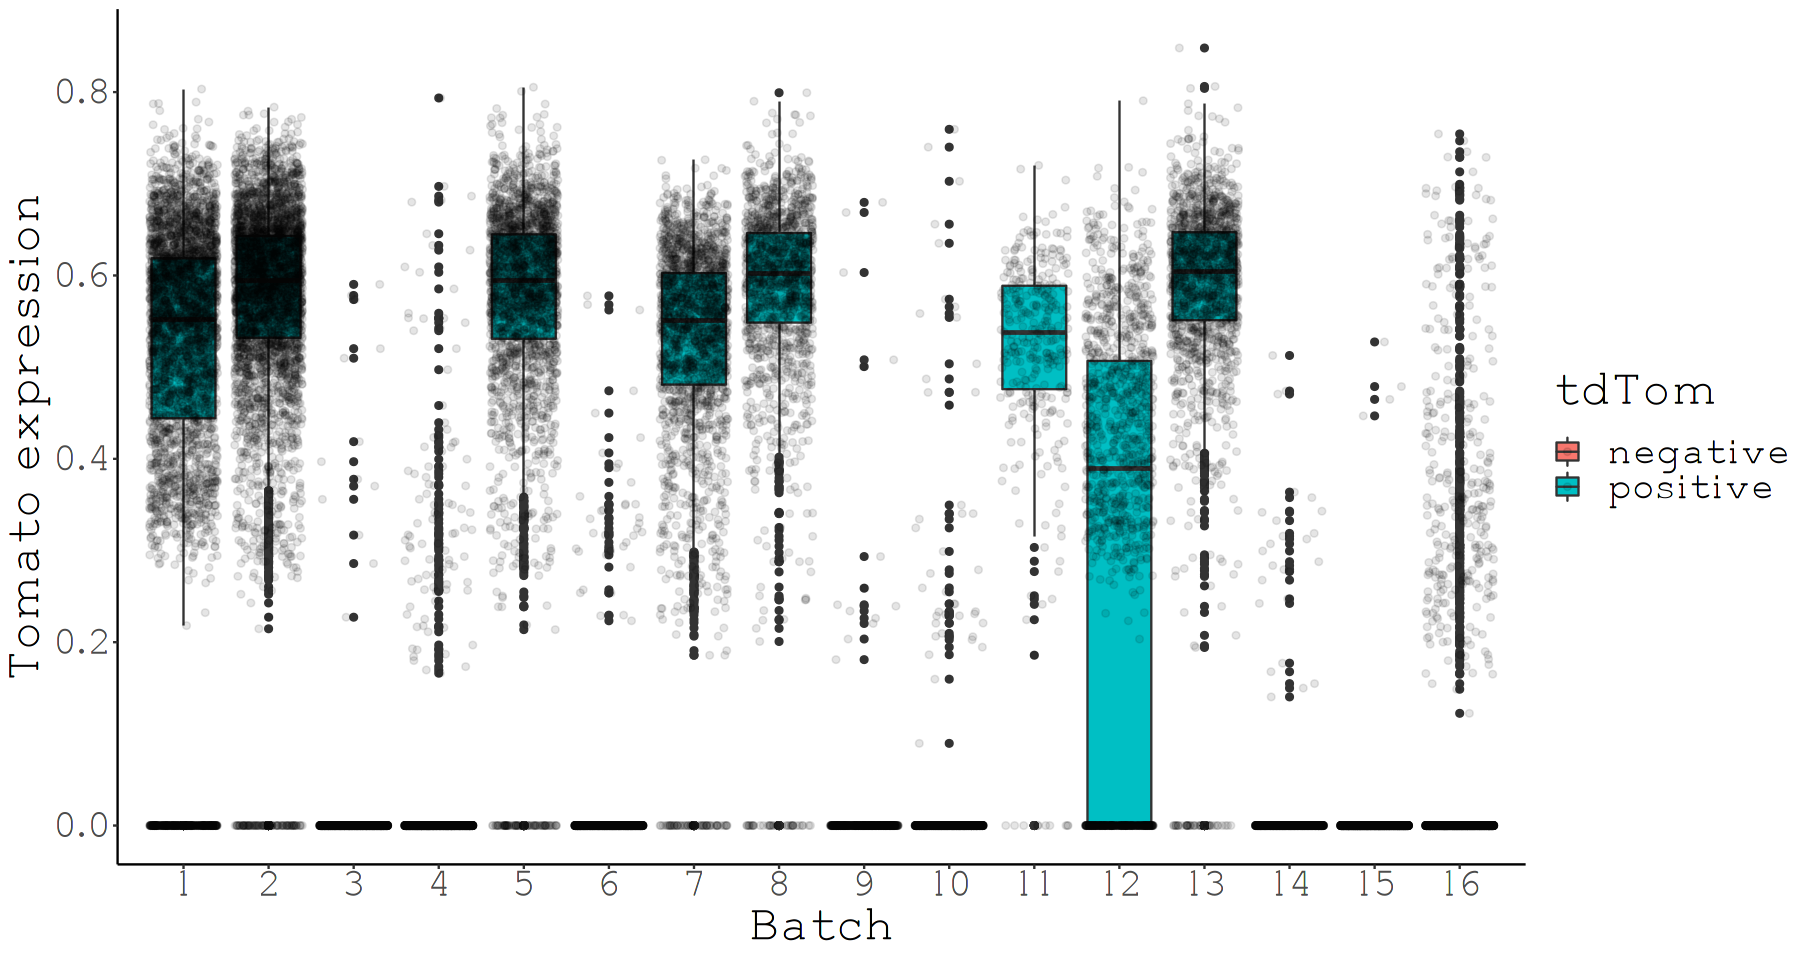

In [45]:
p6 = ggplot(meta, aes(as.factor(batch), log10(tdtom_count+1), group=batch, fill=tdTom)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')

options(repr.plot.width=15, repr.plot.height=8)
p6
## Result is as expected, will probably look better after normalisation/scaling

In [54]:
head(meta)

,sample,closest.cell,cell,Sample_name,barcode,batch,batch_name,tdTom,index,stage,...,louvain_cluster,celltype.mapped,celltype_original.mapped,stage.mapped,celltype.score,celltype_original.score,cellstage.score,umapX.mapped,umapY.mapped,embryo_pool
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,...,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,cell_130410,cell_1,MLT_31+ Tom,AAACCCAAGATGTTCC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,1,E8.5,...,20,Erythroid,Erythroid3,E8.5,1.0000000,1.0000000,0.8333333,8.894147,-4.379566,1
2,1,ext_cell_65004,cell_2,MLT_31+ Tom,AAACCCATCAGACCTA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,2,E8.5,...,11,Mesenchyme,Mesenchyme,E9.0,1.0000000,1.0000000,0.4666667,12.375899,-3.950081,1
3,1,cell_69799,cell_3,MLT_31+ Tom,AAACGAACAATGTTGC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,3,E8.5,...,17,Anterior somitic tissues,Paraxial mesoderm,E8.25,0.9666667,1.0000000,0.5000000,19.298925,10.329799,1
4,1,cell_93369,cell_4,MLT_31+ Tom,AAACGAACACACCAGC,1,SLX-21143_SITTA2_HTJH3DSX2,positive,4,E8.5,...,20,Erythroid,Erythroid2,E8.25,1.0000000,0.5333333,0.8000000,5.619335,-5.187152,1
5,1,cell_136074,cell_5,MLT_31+ Tom,AAACGAAGTGATAGTA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,5,E8.5,...,20,Erythroid,Erythroid3,E8.5,1.0000000,1.0000000,0.8666667,8.613827,-5.146487,1
6,1,ext_cell_338973,cell_6,MLT_31+ Tom,AAACGAAGTTAAGACA,1,SLX-21143_SITTA2_HTJH3DSX2,positive,6,E8.5,...,7,Dorsal spinal cord progenitors,Spinal cord,E9.25,0.3000000,0.7333333,0.5666667,13.251280,17.152754,1


In [60]:
stage = 'E7.5'
nrow(meta[meta$tdTom=='positive' & meta$celltype.mapped=='Erythroid' & meta$stage==stage,])
nrow(meta[meta$tdTom=='negative' & meta$celltype.mapped=='Erythroid' & meta$stage==stage,])

stage = 'E8.5'
nrow(meta[meta$tdTom=='positive' & meta$celltype.mapped=='Erythroid' & meta$stage==stage,])
nrow(meta[meta$tdTom=='negative' & meta$celltype.mapped=='Erythroid' & meta$stage==stage,])

stage = 'E9.5'
nrow(meta[meta$tdTom=='positive' & meta$celltype.mapped=='Erythroid' & meta$stage==stage,])
nrow(meta[meta$tdTom=='negative' & meta$celltype.mapped=='Erythroid' & meta$stage==stage,])

[1] 17

[1] 2

[1] 793

[1] 1046

[1] 26

[1] 393